In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
from scipy.special import gamma
from scipy.optimize import minimize_scalar

In [2]:
# parameters matching ed_momentum.jl (PBC)
L, N = 18, 12
t_hop, V = 1.0, 1.0

configs = [
    {"tp": 0.0,  "Vp": 0.0,  "label": r"integrable ($t'=0$, $V'=0$)"},
    {"tp": 0.32, "Vp": 0.32, "label": r"thermalizing ($t'=0.32$, $V'=0.32$)"},
]

dfs = {}
for cfg in configs:
    tp, Vp = cfg["tp"], cfg["Vp"]
    df = pd.read_csv(f"results/ed_ksectors_L{L}_N{N}_tp{tp}_Vp{Vp}.csv", comment="#")
    dfs[(tp, Vp)] = df
    print(f"tp={tp}, Vp={Vp}: {len(df)} eigenstates across {df['sector'].nunique()} momentum sectors")

tp=0.0, Vp=0.0: 18564 eigenstates across 18 momentum sectors
tp=0.32, Vp=0.32: 18564 eigenstates across 18 momentum sectors


## ETH plot

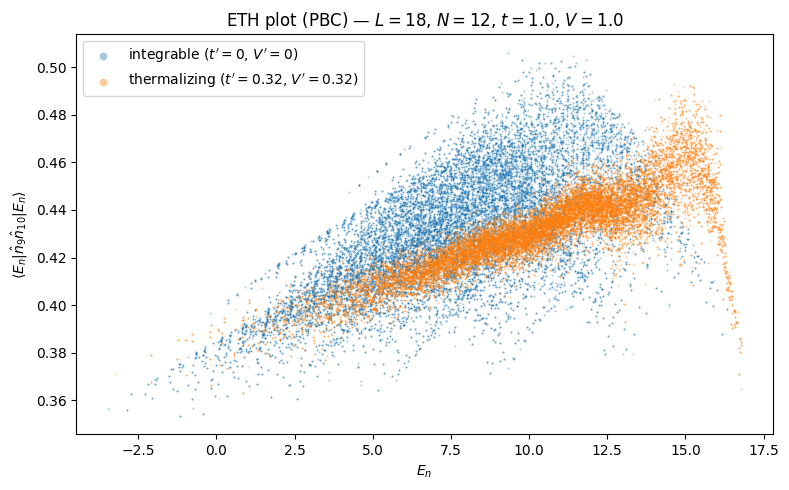

In [3]:
j1, j2 = L // 2, L // 2 + 1   # 1-indexed display labels (sites 9 and 10 for L=18)

fig, ax = plt.subplots(figsize=(8, 5))

for cfg in configs:
    tp, Vp = cfg["tp"], cfg["Vp"]
    df = dfs[(tp, Vp)]
    ax.scatter(df["energy"], df["O_expval"], s=2, alpha=0.4, linewidths=0, label=cfg["label"])

ax.set_xlabel(r"$E_n$")
ax.set_ylabel(rf"$\langle E_n | \hat{{n}}_{{{j1}}} \hat{{n}}_{{{j2}}} | E_n \rangle$")
ax.set_title(rf"ETH plot (PBC) — $L={L}$, $N={N}$, $t={t_hop}$, $V={V}$")
ax.legend(markerscale=4)

plt.tight_layout()
plt.show()

## Level spacing statistics

- **Poisson** (exponential): integrable / non-thermalizing
- **GOE** (Wigner surmise): chaotic / thermalizing
- **Brody** distribution interpolates between the two; $\beta=0$ is Poisson, $\beta=1$ is GOE

In [4]:
def level_spacing(evals, deg=10):
    """Unfold spectrum via polynomial fit to staircase, return normalised spacings."""
    evals = np.sort(evals)
    D = len(evals)
    cut = int(0.10 * D)
    evals_bulk = evals[cut : D - cut]
    N_bulk = np.arange(1, len(evals_bulk) + 1)
    coeffs = np.polyfit(evals_bulk, N_bulk, deg)
    p = np.poly1d(coeffs)
    eps = p(evals_bulk)
    return np.diff(eps)

def brody_b(beta):
    return gamma((beta + 2) / (beta + 1)) ** (beta + 1)

def brody_pdf(s, beta):
    s = np.asarray(s)
    b = brody_b(beta)
    return (beta + 1) * b * (s ** beta) * np.exp(-b * s ** (beta + 1))

def fit_brody_beta_mle(s):
    s = np.asarray(s, dtype=float)
    s = s[s > 0]
    def neg_loglike(beta):
        if beta < 0 or beta > 1:
            return np.inf
        return -np.sum(np.log(brody_pdf(s, beta) + 1e-300))
    result = minimize_scalar(neg_loglike, bounds=(0, 1), method="bounded")
    return result.x, result

tp=0.0, Vp=0.0: pooled 6601 spacings — Brody β = 0.0084
tp=0.32, Vp=0.32: pooled 6601 spacings — Brody β = 0.9294


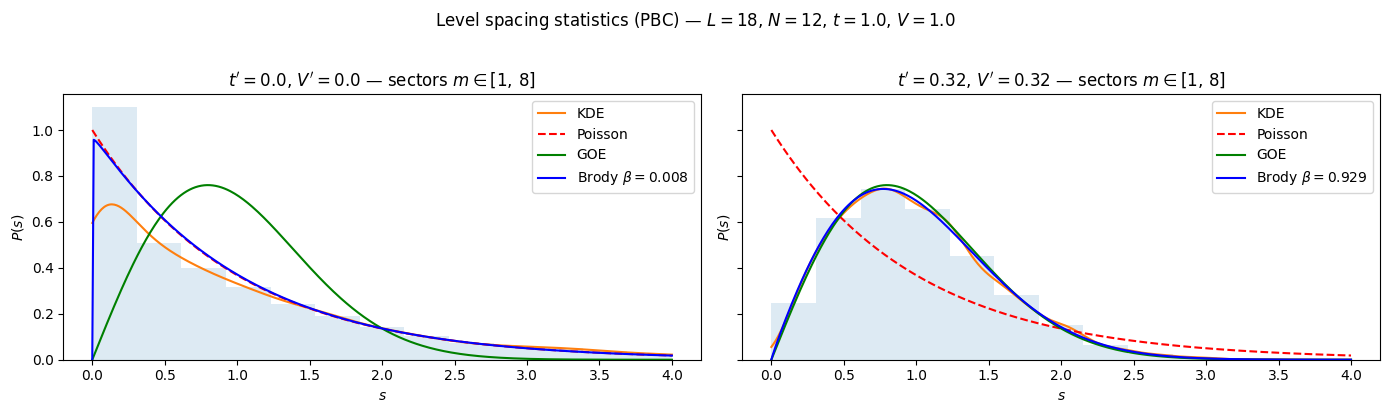

In [5]:
# Use only sectors m ∈ {1, ..., L//2-1}: exclude m=0 (k=0 has extra inversion
# symmetry) and m=L//2 (k=π has extra PT symmetry for even L). Sectors m and
# L-m are related by spatial inversion, so we take only one from each pair.
valid_m = list(range(1, L // 2)) if L % 2 == 0 else list(range(1, (L - 1) // 2 + 1))

s_vals  = np.linspace(0, 4, 400)
poisson = np.exp(-s_vals)
goe     = (np.pi * s_vals / 2) * np.exp(-np.pi * s_vals**2 / 4)

fig, axes = plt.subplots(1, len(configs), figsize=(7 * len(configs), 4), sharey=True)

for ax, cfg in zip(axes, configs):
    tp, Vp = cfg["tp"], cfg["Vp"]
    df = dfs[(tp, Vp)]

    s_list = []
    for m in valid_m:
        evals = np.sort(df[df["sector"] == m]["energy"].to_numpy())
        if len(evals) > 2:
            s_list.append(level_spacing(evals))

    s_all = np.concatenate(s_list)
    beta_fit, _ = fit_brody_beta_mle(s_all)

    bin_number = int(np.log2(len(s_all)) + 1)
    kde   = sts.gaussian_kde(s_all)
    xgrid = np.linspace(0, 4, 500)

    ax.hist(s_all, bins=bin_number, density=True, range=(0, 4), alpha=0.15)
    ax.plot(xgrid, kde(xgrid), label="KDE")
    ax.plot(s_vals, poisson, "r--", label="Poisson")
    ax.plot(s_vals, goe,     "g-",  label="GOE")
    ax.plot(s_vals, brody_pdf(s_vals, beta_fit), "b-",
            label=rf"Brody $\beta={beta_fit:.3f}$")

    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$P(s)$")
    ax.set_title(rf"$t'={tp}$, $V'={Vp}$ — sectors $m \in [1,\,{L//2 - 1}]$")
    ax.legend()

    print(f"tp={tp}, Vp={Vp}: pooled {len(s_all)} spacings — Brody β = {beta_fit:.4f}")

fig.suptitle(
    rf"Level spacing statistics (PBC) — $L={L}$, $N={N}$, $t={t_hop}$, $V={V}$",
    y=1.02
)
plt.tight_layout()
plt.show()